In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import joblib

In [2]:
df = pd.read_csv(
    r"C:\Users\ravsi\Downloads\Conjunto de datos para 2a. evaluación-20260809\comprar_alquilar.csv"
)

In [3]:
print("Forma:", df.shape)
print("Columnas:", df.columns.tolist())
print("Nulos:", df.isnull().sum().sum())
df.head()

Forma: (202, 10)
Columnas: ['ingresos', 'gastos_comunes', 'pago_coche', 'gastos_otros', 'ahorros', 'vivienda', 'estado_civil', 'hijos', 'trabajo', 'comprar']
Nulos: 0


,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
0,6000,1000,0,600,50000,400000,0,2,2,1
1,6745,944,123,429,43240,636897,1,3,6,0
2,6455,1033,98,795,57463,321779,2,1,8,1
3,7098,1278,15,254,54506,660933,0,0,3,0
4,6167,863,223,520,41512,348932,0,0,3,1


In [4]:
X = df.drop(columns=["comprar"])
y = df["comprar"]  # 1 = comprar, 0 = alquilar
print("Variables usadas en PCA:", X.columns.tolist())
print("Forma de X:", X.shape)
print("Distribución comprar:")
print(y.value_counts())

Variables usadas en PCA: ['ingresos', 'gastos_comunes', 'pago_coche', 'gastos_otros', 'ahorros', 'vivienda', 'estado_civil', 'hijos', 'trabajo']
Forma de X: (202, 9)
Distribución comprar:
comprar
0    135
1     67
Name: count, dtype: int64


In [5]:
pca_sin = PCA(n_components=2)
X_pca_sin = pca_sin.fit_transform(X)
print("Varianza explicada SIN escalar:")
print("PC1:", round(pca_sin.explained_variance_ratio_[0] * 100, 2), "%")
print("PC2:", round(pca_sin.explained_variance_ratio_[1] * 100, 2), "%")
print("Total PC1+PC2:", round(pca_sin.explained_variance_ratio_.sum() * 100, 2), "%")

Varianza explicada SIN escalar:
PC1: 98.99 %
PC2: 1.01 %
Total PC1+PC2: 99.99 %


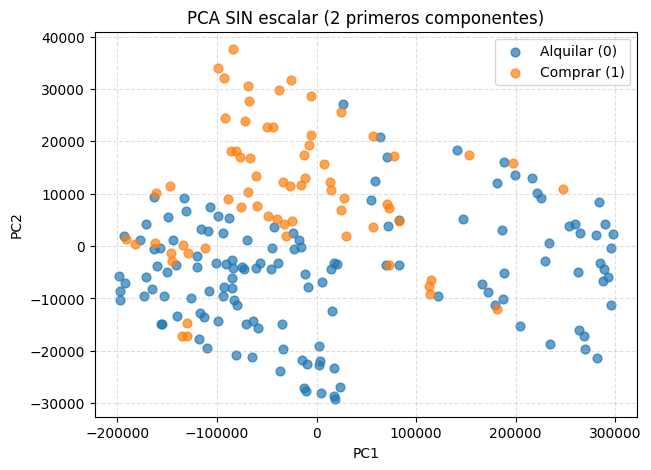

In [6]:
plt.figure(figsize=(7, 5))
plt.scatter(
    X_pca_sin[y == 0, 0], X_pca_sin[y == 0, 1],
    alpha=0.7, label="Alquilar (0)", s=40
)
plt.scatter(
    X_pca_sin[y == 1, 0], X_pca_sin[y == 1, 1],
    alpha=0.7, label="Comprar (1)", s=40
)
plt.title("PCA SIN escalar (2 primeros componentes)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca_con = PCA(n_components=2)
X_pca_con = pca_con.fit_transform(X_scaled)
print("Varianza explicada CON escalar:")
print("PC1:", round(pca_con.explained_variance_ratio_[0] * 100, 2), "%")
print("PC2:", round(pca_con.explained_variance_ratio_[1] * 100, 2), "%")
print("Total PC1+PC2:", round(pca_con.explained_variance_ratio_.sum() * 100, 2), "%")

Varianza explicada CON escalar:
PC1: 29.91 %
PC2: 23.29 %
Total PC1+PC2: 53.21 %


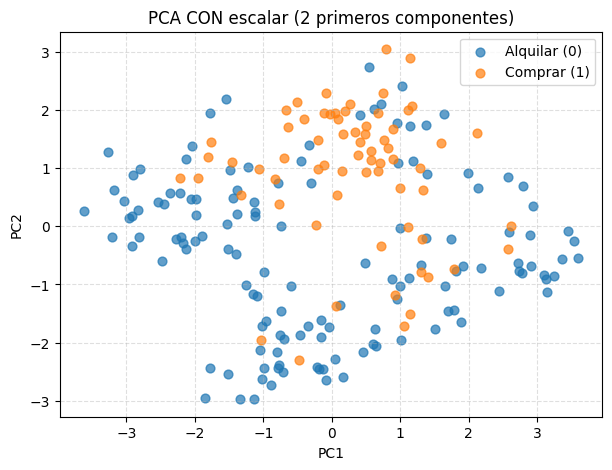

In [8]:
plt.figure(figsize=(7, 5))
plt.scatter(
    X_pca_con[y == 0, 0], X_pca_con[y == 0, 1],
    alpha=0.7, label="Alquilar (0)", s=40
)
plt.scatter(
    X_pca_con[y == 1, 0], X_pca_con[y == 1, 1],
    alpha=0.7, label="Comprar (1)", s=40
)
plt.title("PCA CON escalar (2 primeros componentes)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

In [9]:
pca_full = PCA()
pca_full.fit(X_scaled)
varianza = pca_full.explained_variance_ratio_
varianza_acum = np.cumsum(varianza)
print("Varianza acumulada por componente:")
for i, v in enumerate(varianza_acum, start=1):
    print(f"PC1 a PC{i}: {v*100:.2f}%")

Varianza acumulada por componente:
PC1 a PC1: 29.91%
PC1 a PC2: 53.21%
PC1 a PC3: 64.92%
PC1 a PC4: 75.61%
PC1 a PC5: 85.24%
PC1 a PC6: 90.87%
PC1 a PC7: 95.02%
PC1 a PC8: 98.03%
PC1 a PC9: 100.00%


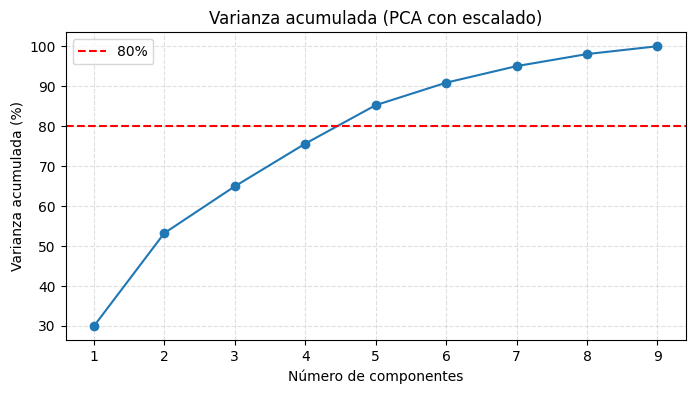

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(varianza_acum) + 1), varianza_acum * 100, marker="o")
plt.axhline(80, color="red", linestyle="--", label="80%")
plt.title("Varianza acumulada (PCA con escalado)")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada (%)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


In [11]:
n_componentes = int(np.argmax(varianza_acum >= 0.80) + 1)
print("\nComponentes elegidos:", n_componentes)
print("Varianza conservada:", round(varianza_acum[n_componentes - 1] * 100, 2), "%")
print("Justificación: se elige el menor número de componentes que conserve al menos el 80% de la información.")


Componentes elegidos: 5
Varianza conservada: 85.24 %
Justificación: se elige el menor número de componentes que conserve al menos el 80% de la información.


In [12]:
pca_final = PCA(n_components=n_componentes)
X_reducido = pca_final.fit_transform(X_scaled)
print("Forma original:", X.shape)
print("Forma reducida:", X_reducido.shape)
print("Varianza total conservada:", round(pca_final.explained_variance_ratio_.sum() * 100, 2), "%")
paquete_modelo = {
    "scaler": scaler,
    "pca": pca_final,
    "n_componentes": n_componentes,
    "features": list(X.columns)
}
joblib.dump(paquete_modelo, "modelo_pca_comprar_alquilar.joblib")
print("Modelo guardado como: modelo_pca_comprar_alquilar.joblib")

Forma original: (202, 9)
Forma reducida: (202, 5)
Varianza total conservada: 85.24 %
Modelo guardado como: modelo_pca_comprar_alquilar.joblib
